In [ ]:
import sys
# Uninstall conflicting packages to ensure a clean slate
!{sys.executable} -m pip uninstall -y numpy pandas

# Install numpy version compatible with node2vec and pandas 2.2.2
# pandas==2.2.2 requires numpy>=1.23.2,<2.0.0
!{sys.executable} -m pip install numpy==1.26.4

# Install pandas version required by google-colab, which is compatible with numpy 1.x
!{sys.executable} -m pip install pandas==2.2.2

# Install other dependencies
!{sys.executable} -m pip install torch-geometric
!{sys.executable} -m pip install node2vec
!{sys.executable} -m pip install gprofiler-official


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pymc 5.28.4 requires pandas>=0.24.0, which is not installed.
pysal 25.7 requires pandas>=1.4, which is not installed.
prophet 1.3.0 requires pandas>=1.0.4, which is not installed.
dopamine-rl 4.1.2 requires pandas>=0.24.2, which is not installed.
statsmodels 0.14.6 requires pandas!=2.1.0,>=1.4, which is not installed.
spaghetti 1.7.6 requires pandas!=1.5.0,>=1.4, which is not installed.
seaborn 0.13.2 req

In [ ]:

import random
import requests
import numpy as np
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt

from node2vec import Node2Vec
from gprofiler import GProfiler

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GATConv
from sklearn.metrics import roc_curve, auc

# =========================================================
# REPRODUCIBILITY
# =========================================================

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# =========================================================
# STEP 1 — SEED GENES
# =========================================================

seed_genes = [

    "TNF", "IL6", "IL1B", "CXCL8", "CCL2",

    "VEGFA", "EGF", "FGF2", "TGFB1", "AKT1",

    "MMP9", "COL1A1", "COL3A1", "PLAU", "TIMP1",

    "INS", "IGF1", "SIRT1", "HIF1A", "NOS3"
]

# =========================================================
# STEP 2 — FETCH REAL STRING NETWORK
# =========================================================

def fetch_string_network():

    url = "https://string-db.org/api/json/network"

    params = {

        "identifiers": "%0d".join(seed_genes),

        "species": 9606,

        "required_score": 700,

        "add_nodes": 380
    }

    response = requests.post(url, data=params)

    if response.status_code != 200:
        raise Exception("STRING API Failed")

    return response.json()

string_data = fetch_string_network()

print(f"Retrieved {len(string_data)} interactions.")

# =========================================================
# STEP 3 — BUILD HEALTHY NETWORK
# =========================================================

G_healthy = nx.Graph()

for interaction in string_data:

    p1 = interaction['preferredName_A']

    p2 = interaction['preferredName_B']

    score = interaction['score']

    G_healthy.add_edge(

        p1,
        p2,

        weight=score
    )

print(f"Healthy Nodes: {G_healthy.number_of_nodes()}")
print(f"Healthy Edges: {G_healthy.number_of_edges()}")

# =========================================================
# STEP 4 — SIMULATED BIOLOGICAL DISRUPTION
# =========================================================
# PHASE 2
# =========================================================

G_diabetic = G_healthy.copy()

edges_to_remove = []

for u, v, data in G_diabetic.edges(data=True):

    weight = data['weight']

    disruption_probability = 0.15

    # Stronger disruption for master regulators

    if u in seed_genes or v in seed_genes:

        disruption_probability = 0.50

    # Weak edges break easier

    if weight < 0.80:

        disruption_probability += 0.20

    if random.random() < disruption_probability:

        edges_to_remove.append((u, v))

G_diabetic.remove_edges_from(edges_to_remove)

print(f"Diabetic Edges: {G_diabetic.number_of_edges()}")

# =========================================================
# STEP 5 — CENTRALITY ANALYSIS
# =========================================================

centrality_healthy = nx.degree_centrality(G_healthy)

centrality_diabetic = nx.degree_centrality(G_diabetic)

proteins = list(G_healthy.nodes())

results = []

for protein in proteins:

    results.append({

        "Protein": protein,

        "Healthy_Centrality":
            centrality_healthy.get(protein, 0),

        "Diabetic_Centrality":
            centrality_diabetic.get(protein, 0)
    })

df_analysis = pd.DataFrame(results)

df_analysis['Hub_Shift'] = (

    df_analysis['Healthy_Centrality'] -

    df_analysis['Diabetic_Centrality']
)

Retrieved 9258 interactions.
Healthy Nodes: 400
Healthy Edges: 9258
Diabetic Edges: 6409



Top Disrupted Proteins
    Protein  Hub_Shift
11      IL6   0.363409
29     IL1B   0.318296
24      TNF   0.293233
30    CXCL8   0.260652
28     CCL2   0.213033
52      EGF   0.213033
114    AKT1   0.197995
124   TGFB1   0.192982
111     INS   0.187970
66     MMP9   0.185464
209    IGF1   0.185464
55     FGF2   0.132832
25     IL10   0.100251
134     FN1   0.095238
278   HIF1A   0.095238


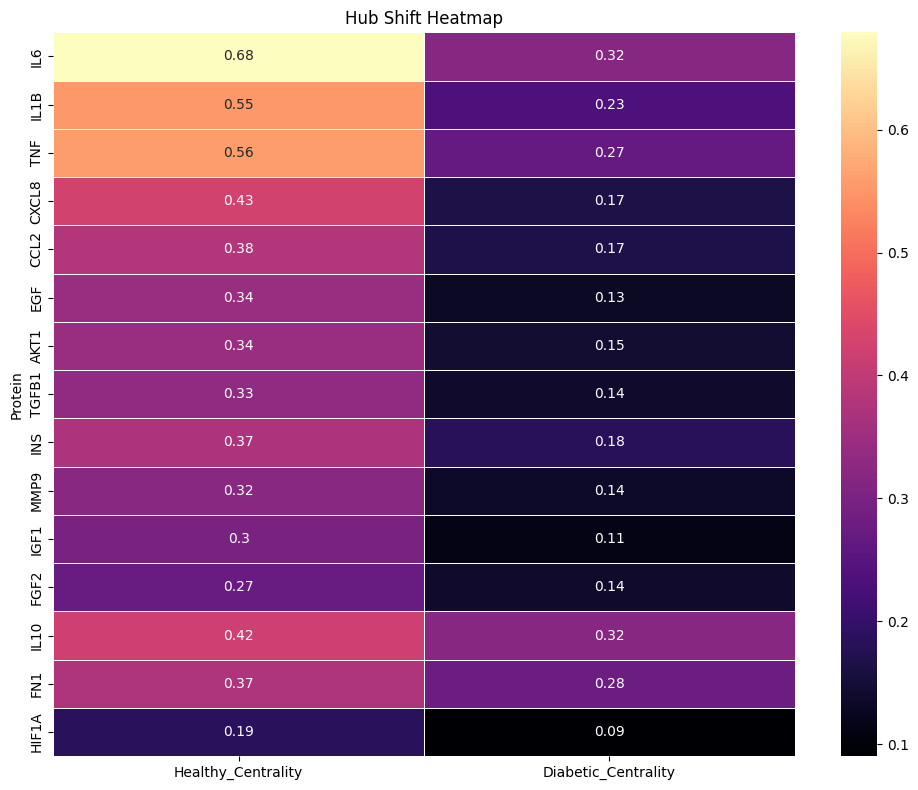

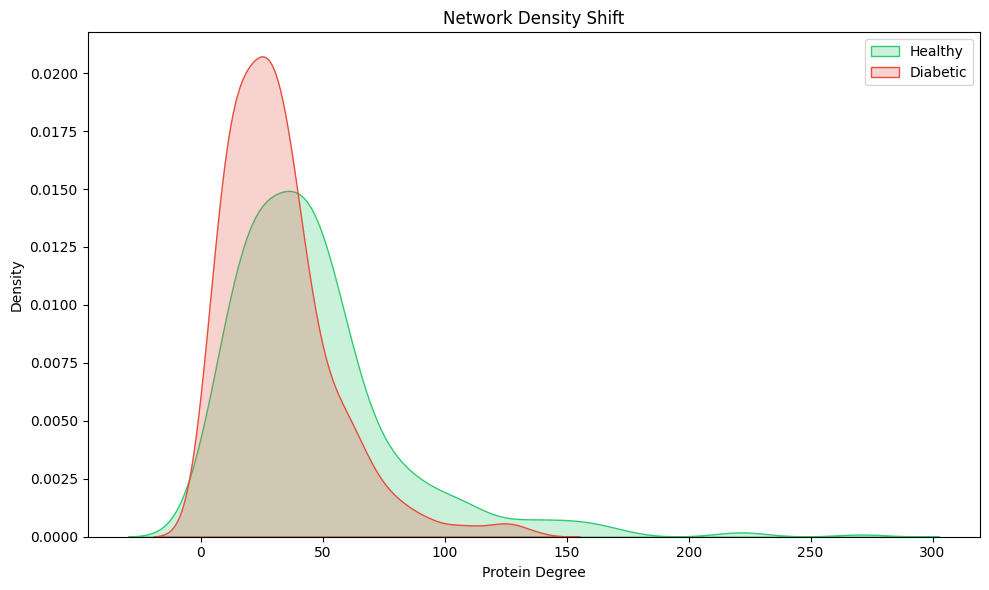


Training Node2Vec...


Computing transition probabilities:   0%|          | 0/400 [00:00<?, ?it/s]

In [ ]:
# =========================================================
# STEP 6 — TOP DISRUPTED PROTEINS
# =========================================================

top_disrupted = df_analysis.sort_values(

    by='Hub_Shift',

    ascending=False

).head(15)

print("\nTop Disrupted Proteins")

print(top_disrupted[['Protein', 'Hub_Shift']])

# =========================================================
# STEP 7 — HUB SHIFT HEATMAP
# =========================================================

heatmap_data = top_disrupted.set_index('Protein')[

    ['Healthy_Centrality', 'Diabetic_Centrality']

]

plt.figure(figsize=(10, 8))

sns.heatmap(

    heatmap_data,

    annot=True,

    cmap="magma",

    linewidths=0.5
)

plt.title("Hub Shift Heatmap")

plt.tight_layout()

plt.savefig("Hub_Shift_Heatmap.png", dpi=300)

plt.show()

# =========================================================
# STEP 8 — DEGREE DISTRIBUTION
# =========================================================

healthy_degrees = [d for _, d in G_healthy.degree()]

diabetic_degrees = [d for _, d in G_diabetic.degree()]

plt.figure(figsize=(10, 6))

sns.kdeplot(

    healthy_degrees,

    fill=True,

    label='Healthy',

    color='#2ecc71'
)

sns.kdeplot(

    diabetic_degrees,

    fill=True,

    label='Diabetic',

    color='#e74c3c'
)

plt.title("Network Density Shift")

plt.xlabel("Protein Degree")

plt.ylabel("Density")

plt.legend()

plt.tight_layout()

plt.savefig("Degree_Distribution.png", dpi=300)

plt.show()

# =========================================================
# STEP 9 — NODE2VEC FEATURES
# =========================================================

print("\nTraining Node2Vec...")

node2vec = Node2Vec(

    G_healthy,

    dimensions=128,

    walk_length=20,

    num_walks=100,

    workers=2,

    seed=42
)

n2v_model = node2vec.fit(

    window=10,

    min_count=1
)

proteins = list(G_healthy.nodes())

node_map = {

    node: idx

    for idx, node in enumerate(proteins)
}

X = np.array([

    n2v_model.wv[node]

    for node in proteins
])

X = torch.tensor(X, dtype=torch.float)

# =========================================================
# STEP 10 — EDGE INDEX
# =========================================================

def convert_edges(graph):

    edges = []

    for u, v in graph.edges():

        edges.append([

            node_map[u],
            node_map[v]
        ])

        edges.append([

            node_map[v],
            node_map[u]
        ])

    return torch.tensor(edges).t().contiguous()

edge_index_healthy = convert_edges(G_healthy)

edge_index_diabetic = convert_edges(G_diabetic)

# =========================================================
# STEP 11 — GAT MODEL
# =========================================================
# PHASE 3
# =========================================================

class GATModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.gat1 = GATConv(

            128,
            128,

            heads=4,

            dropout=0.3
        )

        self.gat2 = GATConv(

            128 * 4,
            128,

            heads=1,

            dropout=0.3
        )

    def forward(self, x, edge_index):

        x = self.gat1(x, edge_index)

        x = F.elu(x)

        x = self.gat2(x, edge_index)

        return x

model = GATModel()

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.003
)



Training GAT Model...
Epoch 000 | Loss: 0.9285
Epoch 010 | Loss: 0.5460
Epoch 020 | Loss: 0.4853
Epoch 030 | Loss: 0.4592
Epoch 040 | Loss: 0.4376
Epoch 050 | Loss: 0.4254
Epoch 060 | Loss: 0.4041
Epoch 070 | Loss: 0.3878
Epoch 080 | Loss: 0.3841
Epoch 090 | Loss: 0.3584


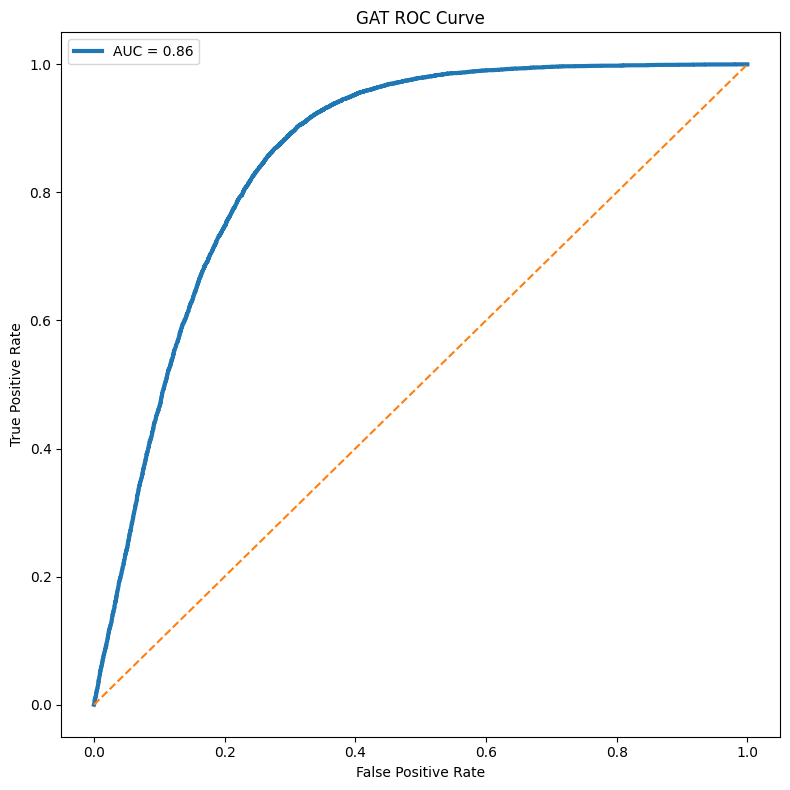


Final ROC-AUC: 0.8565


In [ ]:
# =========================================================
# STEP 12 — TRAINING
# =========================================================

print("\nTraining GAT Model...")

model.train()

for epoch in range(100):

    optimizer.zero_grad()

    z = model(X, edge_index_healthy)

    # Positive edges

    pos_scores = (

        z[edge_index_healthy[0]] *

        z[edge_index_healthy[1]]

    ).sum(dim=-1)

    # Negative edges

    neg_u = torch.randint(

        0,

        len(proteins),

        (len(pos_scores),)
    )

    neg_v = torch.randint(

        0,

        len(proteins),

        (len(pos_scores),)
    )

    neg_scores = (

        z[neg_u] *

        z[neg_v]

    ).sum(dim=-1)

    loss = torch.mean(

        F.relu(1 - pos_scores + neg_scores)
    )

    loss.backward()

    optimizer.step()

    if epoch % 10 == 0:

        print(

            f"Epoch {epoch:03d} | "

            f"Loss: {loss.item():.4f}"
        )

# =========================================================
# STEP 13 — ROC CURVE
# =========================================================

positive_scores = torch.sigmoid(

    pos_scores

).detach().numpy()

negative_scores = torch.sigmoid(

    neg_scores

).detach().numpy()

y_true = np.concatenate([

    np.ones(len(positive_scores)),

    np.zeros(len(negative_scores))
])

y_scores = np.concatenate([

    positive_scores,

    negative_scores
])

fpr, tpr, _ = roc_curve(

    y_true,

    y_scores
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 8))

plt.plot(

    fpr,
    tpr,

    lw=3,

    label=f"AUC = {roc_auc:.2f}"
)

plt.plot(

    [0, 1],
    [0, 1],

    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("GAT ROC Curve")

plt.legend()

plt.tight_layout()

plt.savefig("ROC_Curve.png", dpi=300)

plt.show()

print(f"\nFinal ROC-AUC: {roc_auc:.4f}")


Top Therapeutic Targets
      Protein  Disruption_Score
398     THEM4          0.055884
399     MTCP1          0.042813
396    TBC1D4          0.031465
393    IGFBP6          0.030303
377     IGF2R          0.028304
379  IGHV3-72          0.028007
349      CSH1          0.026385
350       GH1          0.025654
376    IGFBP2          0.024136
364      DDR2          0.024097

Top Enriched Pathways
  source              native                                        name  \
0   REAC  REAC:R-HSA-6785807  Interleukin-4 and Interleukin-13 signaling   
1  GO:BP          GO:0030335       positive regulation of cell migration   
2  GO:BP          GO:2000147        positive regulation of cell motility   
3  GO:BP          GO:0040017           positive regulation of locomotion   
4     WP           WP:WP3624                               Lung fibrosis   
5  GO:BP          GO:0040011                                  locomotion   
6  GO:BP          GO:0030334                regulation of cell migra

/tmp/ipykernel_14418/3985005344.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


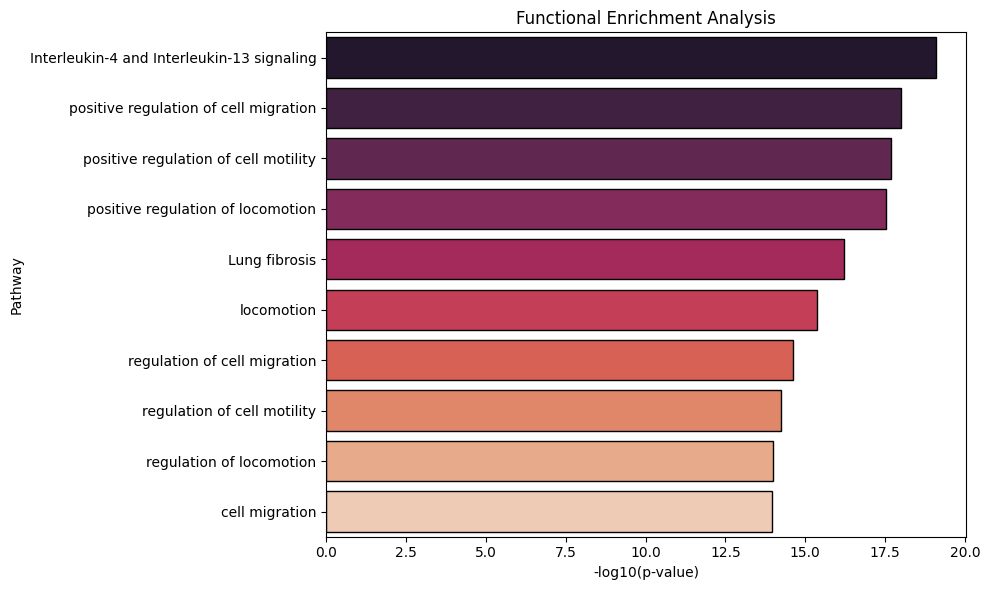


Project Completed Successfully.


In [ ]:
# =========================================================
# STEP 14 — THERAPEUTIC TARGET DISCOVERY
# =========================================================

model.eval()

with torch.no_grad():

    z = model(X, edge_index_healthy)

    disruption_scores = []

    for i, node in enumerate(proteins):

        neighbors = list(

            G_diabetic.neighbors(node)

        )

        if len(neighbors) > 0:

            neighbor_indices = [

                node_map[n]

                for n in neighbors
            ]

            error = F.mse_loss(

                z[i].repeat(

                    len(neighbor_indices),

                    1
                ),

                z[neighbor_indices]
            )

            disruption_scores.append({

                "Protein": node,

                "Disruption_Score":
                    error.item()
            })

df_targets = pd.DataFrame(

    disruption_scores

).sort_values(

    by='Disruption_Score',

    ascending=False
)

print("\nTop Therapeutic Targets")

print(df_targets.head(10))

# =========================================================
# STEP 15 — FUNCTIONAL ENRICHMENT
# =========================================================

gp = GProfiler(return_dataframe=True)

top_genes = top_disrupted['Protein'].tolist()

enrichment = gp.profile(

    organism='hsapiens',

    query=top_genes
)

enrichment = enrichment[[

    'source',
    'native',
    'name',
    'p_value'
]].head(10)

print("\nTop Enriched Pathways")

print(enrichment)

# =========================================================
# STEP 16 — ENRICHMENT VISUALIZATION
# =========================================================

plot_df = enrichment.copy()

plot_df['-log10(p)'] = -np.log10(

    plot_df['p_value']
)

plt.figure(figsize=(10, 6))

sns.barplot(

    x='-log10(p)',

    y='name',

    data=plot_df,

    palette='rocket',

    edgecolor='black'
)

plt.title("Functional Enrichment Analysis")

plt.xlabel("-log10(p-value)")

plt.ylabel("Pathway")

plt.tight_layout()

plt.savefig(

    "Functional_Enrichment.png",

    dpi=300
)

plt.show()

# =========================================================
# STEP 17 — NETWORK EXPORT
# =========================================================

nx.write_graphml(

    G_healthy,

    "Healthy_Network.graphml"
)

nx.write_graphml(

    G_diabetic,

    "Diabetic_Network.graphml"
)

# =========================================================
# STEP 18 — SAVE RESULTS
# =========================================================

df_analysis.to_csv(

    "Hub_Shift_Analysis.csv",

    index=False
)

df_targets.to_csv(

    "Therapeutic_Targets.csv",

    index=False
)

enrichment.to_csv(

    "Functional_Enrichment.csv",

    index=False
)

print("\nProject Completed Successfully.")